In [1]:
import rasterio
from rasterio.windows import from_bounds
from rasterio.features import shapes
import numpy as np
import geopandas as gpd
import datetime
import pandas as pd
import matplotlib.pyplot as plt
from torch import nn
import torch
import tqdm
import numpy as np
from sklearn.metrics import mean_squared_error

In [2]:
predictions_rst = "/mnt/sdc/ls89gf/{}_silver_sweep_9_102022.vrt"
area_shp = "/mnt/sdc/tree_density_and_coverage/shapefiles/nasa_validation/senegal_cutlines_intersection_with_tiles.gpkg"
early_dir = "/mnt/sdb/senegal_model/output_predictions/20231114-1601_Model_1_martin_revised_labels_senegal_500ep_0.7norm_tversky04_06/rasters_early"
late_dir = "/mnt/sdb/senegal_model/output_predictions/20231114-1601_Model_1_martin_revised_labels_senegal_500ep_0.7norm_tversky04_06/rasters_late"

In [11]:
def crop2cropland(row):    
    # read agricultural mask with window
    with rasterio.open("/mnt/sdd/downloads_on_drive_d/potapov/2000/2000_potapov_102022.vrt") as src:
        window = rasterio.windows.from_bounds(*row.geometry.bounds, transform=src.transform)
        ag_mask_2000 = src.read(1, window=window)
        ag_mask_2000 = np.where(ag_mask_2000 == 244, 1, 0)
    
    return ag_mask_2000

def downsample(high_res, low_res):
    high_res = high_res[:high_res.shape[0] - high_res.shape[0] % low_res.shape[0], :high_res.shape[1] - high_res.shape[1] % low_res.shape[1]]
    kernel_size = (high_res.shape[0] // low_res.shape[0], high_res.shape[1] // low_res.shape[1])
    stride = kernel_size
    pool = nn.AvgPool2d(kernel_size=kernel_size, stride=stride, divisor_override=1)
    high_res_tensor = torch.tensor(high_res).unsqueeze(0).unsqueeze(0).float()
    high_res_downsampled = pool(high_res_tensor).squeeze(0).squeeze(0).to("cpu").numpy()*0.5
    return high_res_downsampled\
        
import numpy as np
from scipy.ndimage import zoom

def downsample(high_res, low_res):
    # Ensure high_res dimensions are multiples of low_res dimensions
    high_res = high_res[:high_res.shape[0] - high_res.shape[0] % low_res.shape[0], 
                        :high_res.shape[1] - high_res.shape[1] % low_res.shape[1]]
    
    # Calculate the zoom factors
    zoom_factors = (low_res.shape[0] / high_res.shape[0], low_res.shape[1] / high_res.shape[1])
    
    # Downsample using scipy.ndimage.zoom
    high_res_downsampled = zoom(high_res, zoom_factors, order=1)  # order=1 for bilinear interpolation
    

    return high_res_downsampled

def calculate_rmse(y_true, y_pred):
    """
    Calculate RMSE.
    
    Parameters:
    - y_true: array-like of shape (n_samples,) - True values.
    - y_pred: array-like of shape (n_samples,) - Predicted values.
    
    Returns:
    - rmse: float - Root Mean Square Error.
    """
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return rmse

def calculate_relative_rmse(y_true, y_pred):
    """
    Calculate relative RMSE.
    
    Parameters:
    - y_true: array-like of shape (n_samples,) - True values.
    - y_pred: array-like of shape (n_samples,) - Predicted values.
    
    Returns:
    - relative_rmse: float - Relative Root Mean Square Error.
    """
    rmse = calculate_rmse(y_true, y_pred)
    mean_y_true = np.mean(y_true)
    relative_rmse = rmse / mean_y_true
    return relative_rmse
    

In [3]:
gdf = gpd.read_file(area_shp.replace(".gpkg", "_sorted_102022_results.gpkg"), driver="GPKG")

In [4]:
gdf["year_diff"] = gdf["late_year"] - gdf["early_year"]
#filter out nans
gdf = gdf.dropna()
#gdf.to_file(area_shp.replace(".gpkg", "_sorted_102022_results.gpkg"), driver="GPKG")

In [9]:
gdf_filtered_18 = gdf[gdf["year_diff"] > 18]
gdf_filtered_15 = gdf[(gdf["year_diff"] > 15) & (gdf["year_diff"] < 18)]
gdf_filtered_10 = gdf[(gdf["year_diff"] >= 10) & (gdf["year_diff"] < 15)]
gdf_filtered_5 = gdf[(gdf["year_diff"] >= 5) & (gdf["year_diff"] < 10)]
gdf_filtered_2 = gdf[(gdf["year_diff"] >= 2) & (gdf["year_diff"] < 5)]

In [7]:


gdf_filtered_18 = gdf[gdf["year_diff"] > 18]
gdf_filtered_15 = gdf[gdf["year_diff"] > 15]
gdf_filtered_10 = gdf[gdf["year_diff"] > 10]
gdf_filtered_5 = gdf[gdf["year_diff"] > 5]
gdf_filtered_2 = gdf[gdf["year_diff"] > 2]

print(len(gdf), len(gdf_filtered_18), len(gdf_filtered_15), len(gdf_filtered_10), len(gdf_filtered_5), len(gdf_filtered_2))


9025 148 691 3079 7749 8757


/home/rene1337/miniconda3/envs/torch2/lib/python3.9/site-packages/geopandas/geodataframe.py:1443: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/home/rene1337/miniconda3/envs/torch2/lib/python3.9/site-packages/geopandas/geodataframe.py:1443: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/home/rene1337/miniconda3/envs/torch2/lib/python3.9/site-packages/geopandas/geodataframe.py:1443: SettingWithCopyWarning: 
A value is trying to be set on a copy

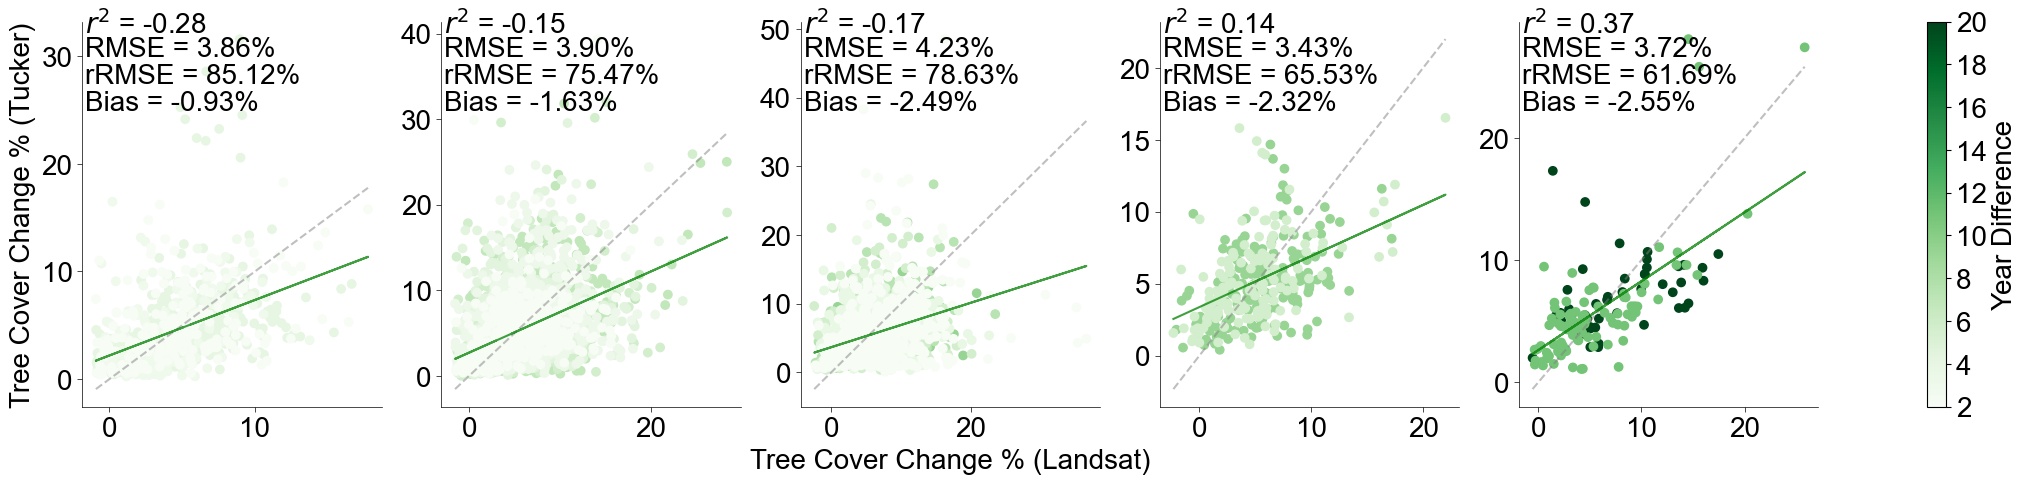

In [ ]:
# calculate r2 of un-bias corrected
from sklearn.metrics import r2_score
# calculate rmse of un-bias corrected
from sklearn.metrics import mean_squared_error
#use bias to correct positive prediction


def plot_scatters(fig, ax, gdf, ax_index, vmin, vmax, fontsize):

    bias = gdf["positive_change_mean"] - gdf["positive_trend_mean"]
    
    gdf["positive_trend_corrected"] = gdf["positive_trend_mean"] + bias.mean()

    # add a line of perfect fit
    ax[ax_index].plot([np.min(gdf["positive_trend_corrected"]*100), 
            np.max(gdf["positive_trend_corrected"]*100)], 
            [np.min(gdf["positive_trend_corrected"]*100), 
            np.max(gdf["positive_trend_corrected"]*100)],
            color='grey', alpha = 0.5, linestyle='--')

    # scatter plot with colour based on year difference
    sc = ax[ax_index].scatter(gdf["positive_trend_corrected"]*100,
                    gdf["positive_change_mean"]*100,
                    c = gdf["year_diff"],
                    cmap = 'Greens',
                    alpha = 1,
                    vmin=vmin,
                    vmax=vmax)

    m, b = np.polyfit(gdf["positive_trend_corrected"]*100, 
                    gdf["positive_change_mean"]*100, 1)

    ax[ax_index].plot(gdf["positive_trend_corrected"]*100, 
            m*gdf["positive_trend_corrected"]*100 + b, 
            color='green', alpha = 0.75)

    ax[ax_index].spines['top'].set_visible(False)
    ax[ax_index].spines['right'].set_visible(False)

    # change color of axes
    ax[ax_index].spines['bottom'].set_color('black')
    ax[ax_index].spines['left'].set_color('black')

    ax[ax_index].spines['bottom'].set_linewidth(0.5)
    ax[ax_index].spines['left'].set_linewidth(0.5)

    # change color of ticks and labels
    ax[ax_index].tick_params(axis='x', colors='black', width = 0.5, labelsize = fontsize)
    ax[ax_index].tick_params(axis='y', colors='black', width = 0.5, labelsize = fontsize)

    # add text to top left with superscript
    ax[ax_index].text(0.01, 0.97, f'$r^2$ = {r2_score(gdf["positive_trend_corrected"], gdf["positive_change_mean"]):.2f}',
                      transform=ax[ax_index].transAxes, fontsize=fontsize)
    
    rRMSE = calculate_relative_rmse(gdf["positive_trend_corrected"]*100, gdf["positive_change_mean"]*100)
    
   
    ax[ax_index].text(0.01, 0.84, f'rRMSE = {rRMSE*100:.2f}%',
                        transform=ax[ax_index].transAxes, fontsize=fontsize)
    
    ax[ax_index].text(0.01, 0.77, f'Bias = {bias.mean()*100:.2f}%',
                        transform=ax[ax_index].transAxes, fontsize=fontsize)
    
    
    ax[ax_index].text(0.01, 0.91, f'RMSE = {mean_squared_error(gdf["positive_trend_corrected"]*100, gdf["positive_change_mean"]*100, squared=False):.2f}%',
                      transform=ax[ax_index].transAxes, fontsize=fontsize)

    #ax[ax_index].set_xlabel("Tree Cover Change % (Landsat)", fontsize=fontsize)

    return fig, ax

from matplotlib import font_manager
# Find the path to the Arial font
arial_font_path = '/usr/share/fonts/truetype/msttcorefonts/Arial.ttf'  # Update this path based on your system

# Add the Arial font to the font manager
font_manager.fontManager.addfont(arial_font_path)

# Set the font to Arial
plt.rcParams['font.family'] = 'Arial'
fontsize = 20
fig, ax = plt.subplots(1, 5, figsize=(28, 5))
fig, ax = plot_scatters(fig, ax, gdf_filtered_2, 0, 2, 20,fontsize)
fig, ax = plot_scatters(fig, ax, gdf_filtered_5, 1, 5, 20,fontsize)
fig, ax = plot_scatters(fig, ax, gdf_filtered_10, 2, 10, 20,fontsize)
fig, ax = plot_scatters(fig, ax, gdf_filtered_15, 3, 15, 20,fontsize)
fig, ax = plot_scatters(fig, ax, gdf_filtered_18, 4, 18, 20,fontsize)

cbar = plt.colorbar(ax[0].collections[0], ax=ax)
cbar.set_label('Year Difference', fontsize=fontsize)
cbar.cmap.set_over('green')
cbar.set_ticklabels([f"{int(i)}" for i in cbar.get_ticks()], fontsize=fontsize)

ax[0].set_ylabel("Tree Cover Change % (Tucker)", fontsize=fontsize)
ax[2].set_xlabel("Tree Cover Change % (Landsat)", fontsize=fontsize)
plt.savefig("/home/rene1337/RSCPH/landsat_tree_analysis/figures/positive_change_comparison_5_v3.pdf", dpi = 1000)
plt.savefig("/home/rene1337/RSCPH/landsat_tree_analysis/figures/positive_change_comparison_5_v3.svg")
plt.show()

In [20]:
sorted_gdf_filtered_18 = gdf_filtered_18.sort_values(by="positive_change_mean", ascending=False)
sorted_gdf_filtered_18.head()
# Remove rows 326, 275, 40 and 61	
print(len(sorted_gdf_filtered_18))
sorted_gdf_filtered_18_dropped = sorted_gdf_filtered_18.drop([326, 275, 40, 61])
sorted_gdf_filtered_18_dropped.head()

148


,area,early_year,late_year,year_diff,location,location_2,positive_trend_sum,negative_trend_sum,positive_change_sum,negative_change_sum,positive_trend_mean,negative_trend_mean,positive_change_mean,negative_change_mean,geometry,positive_trend_corrected
282,4.965903e+06,2002,2021,19,det_Model_1_martin_revised_labels_senegal_500e...,det_Model_1_martin_revised_labels_senegal_500e...,1506.769531,-1.120087,1462.375488,-0.004911,0.283761,-0.044803,0.274161,-0.004911,"MULTIPOLYGON (((-4373274.707 1670393.124, -437...",0.258289
311,2.004202e+06,2002,2021,19,det_Model_1_martin_revised_labels_senegal_500e...,det_Model_1_martin_revised_labels_senegal_500e...,430.241821,-32.174892,192.473938,-159.721466,0.228366,-0.066477,0.137875,-0.164492,"MULTIPOLYGON (((-4376976.240 1704014.585, -437...",0.202895
23,1.362143e+07,2002,2022,20,det_Model_1_martin_revised_labels_senegal_500e...,det_Model_1_martin_revised_labels_senegal_500e...,979.837830,-571.065918,1354.057007,-284.123474,0.104305,-0.089229,0.113700,-0.073058,"MULTIPOLYGON (((-3883621.774 1693722.204, -388...",0.078833
296,3.455545e+06,2002,2021,19,det_Model_1_martin_revised_labels_senegal_500e...,det_Model_1_martin_revised_labels_senegal_500e...,571.598572,-15.712440,418.291321,-29.880688,0.142686,-0.033149,0.110601,-0.042870,"MULTIPOLYGON (((-4373191.525 1672000.076, -437...",0.117214
53,3.679953e+06,2002,2022,20,det_Model_1_martin_revised_labels_senegal_500e...,det_Model_1_martin_revised_labels_senegal_500e...,1532.932373,-24.113440,1250.169922,-19.449932,0.131402,-0.044326,0.106734,-0.039135,"MULTIPOLYGON (((-4360220.712 1720000.001, -436...",0.105930


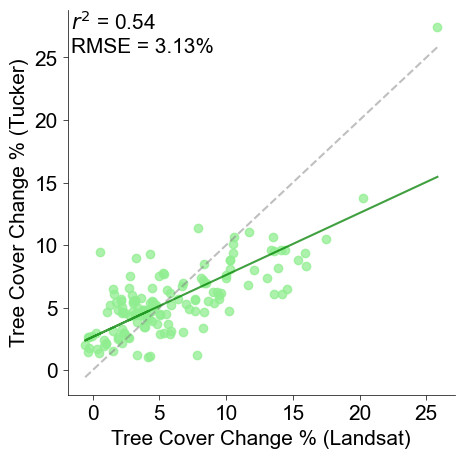

In [44]:
from matplotlib import font_manager
# Find the path to the Arial font
arial_font_path = '/usr/share/fonts/truetype/msttcorefonts/Arial.ttf'  # Update this path based on your system

# Add the Arial font to the font manager
font_manager.fontManager.addfont(arial_font_path)

# Set the font to Arial
plt.rcParams['font.family'] = 'Arial'
fontsize = 15
fig, ax = plt.subplots(figsize=(5, 5))

# add a line of perfect fit
ax.plot([np.min(sorted_gdf_filtered_18_dropped["positive_trend_corrected"]*100), 
        np.max(sorted_gdf_filtered_18_dropped["positive_trend_corrected"]*100)], 
        [np.min(sorted_gdf_filtered_18_dropped["positive_trend_corrected"]*100), 
        np.max(sorted_gdf_filtered_18_dropped["positive_trend_corrected"]*100)],
        color='grey', alpha = 0.5, linestyle='--')

# scatter plot with colour based on year difference
sc = ax.scatter(sorted_gdf_filtered_18_dropped["positive_trend_corrected"]*100,
                sorted_gdf_filtered_18_dropped["positive_change_mean"]*100,
                color = 'lightgreen',
                alpha = 0.75)

m, b = np.polyfit(sorted_gdf_filtered_18_dropped["positive_trend_corrected"]*100, 
                sorted_gdf_filtered_18_dropped["positive_change_mean"]*100, 1)

ax.plot(sorted_gdf_filtered_18_dropped["positive_trend_corrected"]*100, 
        m*sorted_gdf_filtered_18_dropped["positive_trend_corrected"]*100 + b, 
        color='green', alpha = 0.75)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# change color of axes
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)

# change color of ticks and labels
ax.tick_params(axis='x', colors='black', width = 0.5, labelsize = fontsize)
ax.tick_params(axis='y', colors='black', width = 0.5, labelsize = fontsize)

# add text to top left with superscript
ax.text(0.01, 0.95, f'$r^2$ = {r2_score(sorted_gdf_filtered_18_dropped["positive_trend_corrected"], sorted_gdf_filtered_18_dropped["positive_change_mean"]):.2f}',
                    transform=ax.transAxes, fontsize=fontsize)

rRMSE = calculate_relative_rmse(sorted_gdf_filtered_18_dropped["positive_trend_corrected"]*100, sorted_gdf_filtered_18_dropped["positive_change_mean"]*100)


#ax.text(0.01, 0.84, f'rRMSE = {rRMSE*100:.2f}%',
#                    transform=ax.transAxes, fontsize=fontsize)

#ax.text(0.01, 0.77, f'Bias = {bias.mean()*100:.2f}%',
#                    transform=ax.transAxes, fontsize=fontsize)


ax.text(0.01, 0.89, f'RMSE = {mean_squared_error(sorted_gdf_filtered_18_dropped["positive_trend_corrected"]*100, sorted_gdf_filtered_18_dropped["positive_change_mean"]*100, squared=False):.2f}%',
                    transform=ax.transAxes, fontsize=fontsize)


'''cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('Year Difference', fontsize=fontsize)
cbar.cmap.set_over('green')
cbar.set_ticklabels([f"{int(i)}" for i in cbar.get_ticks()], fontsize=fontsize)
'''
ax.set_ylabel("Tree Cover Change % (Tucker)", fontsize=fontsize)
ax.set_xlabel("Tree Cover Change % (Landsat)", fontsize=fontsize)

#plt.savefig("/home/rene1337/RSCPH/landsat_tree_analysis/figures/positive_change_comparison_5_v3.pdf", dpi = 1000)
plt.savefig("/home/rene1337/RSCPH/landsat_tree_analysis/figures/positive_change_comparison_large_time_gap.svg", bbox_inches='tight')
plt.show()

In [6]:
gdf_filtered = gdf

/home/rene1337/miniconda3/envs/torch2/lib/python3.9/site-packages/geopandas/geodataframe.py:1443: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/tmp/ipykernel_456141/1019260993.py:28: UserWarning: FixedFormatter should only be used together with FixedLocator
  cbar.set_ticklabels([f"{int(i)}" for i in cbar.get_ticks()])


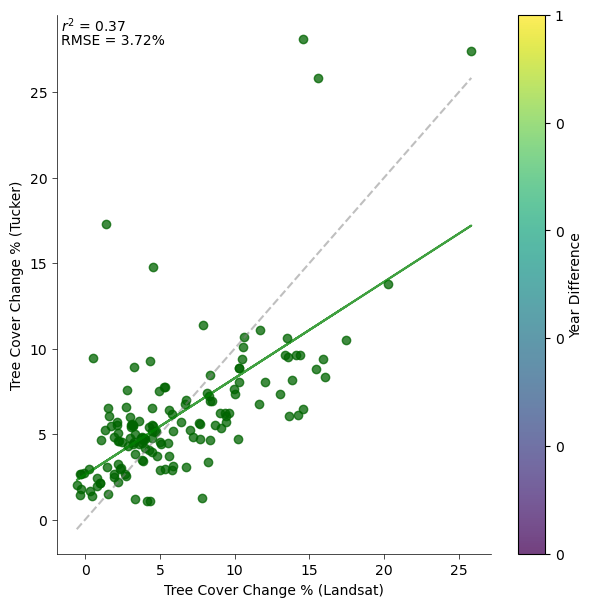

In [7]:
# calculate r2 of un-bias corrected
from sklearn.metrics import r2_score
# calculate rmse of un-bias corrected
from sklearn.metrics import mean_squared_error
#use bias to correct positive prediction

# calculate bias between positive prediction and positive observed
bias = gdf_filtered["positive_change_mean"] - gdf_filtered["positive_trend_mean"]
bias.mean()
gdf_filtered["positive_trend_corrected"] = gdf_filtered["positive_trend_mean"] + bias.mean()

fig, ax = plt.subplots(figsize=(7, 7))

# add a line of perfect fit
plt.plot([np.min(gdf_filtered["positive_trend_corrected"]*100), 
          np.max(gdf_filtered["positive_trend_corrected"]*100)], 
         [np.min(gdf_filtered["positive_trend_corrected"]*100), 
          np.max(gdf_filtered["positive_trend_corrected"]*100)],
         color='grey', alpha = 0.5, linestyle='--')

plt.scatter(gdf_filtered["positive_trend_corrected"]*100,
            gdf_filtered["positive_change_mean"]*100,
            c = "darkgreen", alpha=0.75)

cbar = plt.colorbar(ax.collections[0], ax=ax)
cbar.set_label('Year Difference')
cbar.cmap.set_over('green')
cbar.set_ticklabels([f"{int(i)}" for i in cbar.get_ticks()])

m, b = np.polyfit(gdf_filtered["positive_trend_corrected"]*100, 
                  gdf_filtered["positive_change_mean"]*100, 1)

plt.plot(gdf_filtered["positive_trend_corrected"]*100, 
         m*gdf_filtered["positive_trend_corrected"]*100 + b, 
         color='green', alpha = 0.75)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# change color of axes
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)

# change color of ticks and labels
ax.tick_params(axis='x', colors='black', width = 0.5)
ax.tick_params(axis='y', colors='black', width = 0.5)

# add text to top left with superscript
plt.text(0.01, 0.97, f'$r^2$ = {r2_score(gdf_filtered["positive_trend_corrected"], gdf_filtered["positive_change_mean"]):.2f}', transform=ax.transAxes)
plt.text(0.01, 0.945, f'RMSE = {mean_squared_error(gdf_filtered["positive_trend_corrected"]*100, gdf_filtered["positive_change_mean"]*100, squared=False):.2f}%', transform=ax.transAxes)


plt.xlabel("Tree Cover Change % (Landsat)")
plt.ylabel("Tree Cover Change % (Tucker)")
plt.savefig("/home/rene1337/RSCPH/landsat_tree_analysis/figures/positive_change_comparison_year_diff_lt_3.png", dpi = 1000)
plt.show()

/home/rene1337/miniconda3/envs/torch2/lib/python3.9/site-packages/geopandas/geodataframe.py:1443: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)
/home/rene1337/miniconda3/envs/torch2/lib/python3.9/site-packages/geopandas/geodataframe.py:1443: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


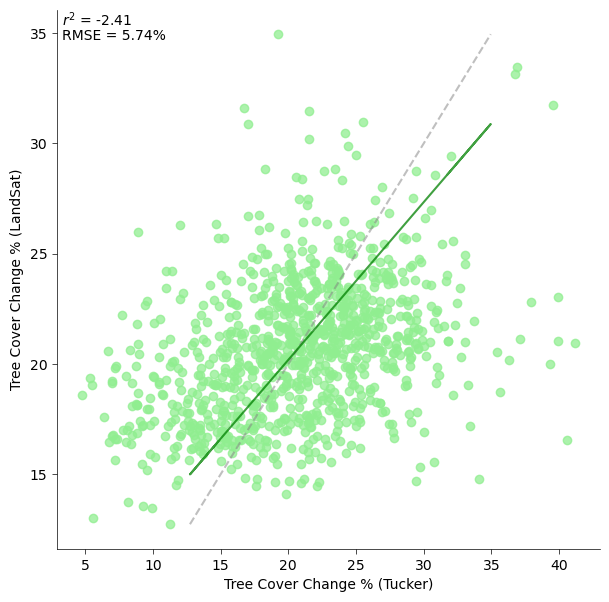

In [66]:
# calculate r2 of un-bias corrected
from sklearn.metrics import r2_score
# calculate rmse of un-bias corrected
from sklearn.metrics import mean_squared_error
#use bias to correct positive prediction

gdf_filtered["negative_trend_mean"] = gdf_filtered["negative_trend_mean"]*-1
gdf_filtered["negative_change_mean"] = gdf_filtered["negative_change_mean"]*-1

# calculate bias between positive prediction and positive observed
bias = gdf_filtered["negative_change_mean"] - gdf_filtered["negative_trend_mean"]
bias.mean()
gdf_filtered["negative_trend_corrected"] = gdf_filtered["negative_trend_mean"] + bias.mean()

fig, ax = plt.subplots(figsize=(7, 7))

# add a line of perfect fit
plt.plot([np.min(gdf_filtered["negative_trend_corrected"]*100), np.max(gdf_filtered["negative_trend_corrected"]*100)], [np.min(gdf_filtered["negative_trend_corrected"]*100), np.max(gdf_filtered["negative_trend_corrected"]*100)], color='grey', alpha = 0.5, linestyle='--')
plt.scatter(gdf_filtered["negative_change_mean"]*100, gdf_filtered["negative_trend_corrected"]*100, color='lightgreen', alpha=0.75)

m, b = np.polyfit(gdf_filtered["negative_trend_corrected"]*100, gdf_filtered["negative_change_mean"]*100, 1)
plt.plot(gdf_filtered["negative_trend_corrected"]*100, m*gdf_filtered["negative_trend_corrected"]*100 + b, color='green', alpha = 0.75)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# change color of axes
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)

# change color of ticks and labels
ax.tick_params(axis='x', colors='black', width = 0.5)
ax.tick_params(axis='y', colors='black', width = 0.5)

# add text to top left with superscript
plt.text(0.01, 0.97, f'$r^2$ = {r2_score(gdf_filtered["negative_trend_corrected"], gdf_filtered["negative_change_mean"]):.2f}', transform=ax.transAxes)
plt.text(0.01, 0.945, f'RMSE = {mean_squared_error(gdf_filtered["negative_trend_corrected"]*100, gdf_filtered["negative_change_mean"]*100, squared=False):.2f}%', transform=ax.transAxes)


plt.xlabel("Tree Cover Change % (Tucker)")
plt.ylabel("Tree Cover Change % (LandSat)")
plt.savefig("/home/rene1337/RSCPH/landsat_tree_analysis/figures/negative_change_comparison_ls7.png", dpi = 1000)

In [ ]:
average_preds_perc = average_preds * 100
average_ys_perc = average_ys * 100

rmse = np.sqrt(np.mean((average_preds_perc - average_ys_perc) ** 2))

print("sklearn_r2 canopy", r2_score(average_ys_perc[:, 0], average_preds_perc[:, 0]))
print("RMSE: ", rmse)

canopy_r2 = val_89_results[-2].compute()
print("torch_r2", canopy_r2)

fig, ax = plt.subplots(figsize=(7, 7))

# add a line of perfect fit
plt.plot([0, np.max(average_ys_perc[:, 0])], [0, np.max(average_ys_perc[:, 0])], color='grey', alpha = 0.5, linestyle='--')
plt.scatter(gdf_filtered["positive_trend_mean"], gdf_filtered["positive_change_mean"], color='lightgreen', alpha=0.75)

# add a line of best fit
m, b = np.polyfit(average_ys_perc[:, 0], average_preds_perc[:, 0], 1)
plt.plot(average_ys_perc[:, 0], m*average_ys_perc[:, 0] + b, color='green', alpha = 0.75)


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# change color of axes
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')

ax.spines['bottom'].set_linewidth(0.5)
ax.spines['left'].set_linewidth(0.5)

# change color of ticks and labels
ax.tick_params(axis='x', colors='black', width = 0.5)
ax.tick_params(axis='y', colors='black', width = 0.5)

# add text to top left with superscript
plt.text(0.01, 0.97, f"$r^2$ = {r2_score(average_ys_perc, average_preds_perc):.2f}", transform=ax.transAxes)
plt.text(0.01, 0.945, f"RMSE = {rmse:.2f}%", transform=ax.transAxes)

plt.xlabel("Tree Cover % (Tucker)")
plt.ylabel("Tree Cover % (LandSat-8/9)")
plt.show()

/home/rene1337/miniconda3/envs/torch2/lib/python3.9/site-packages/geopandas/geodataframe.py:1443: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


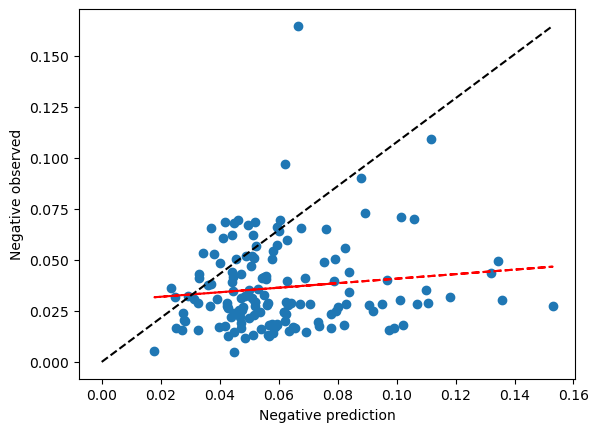

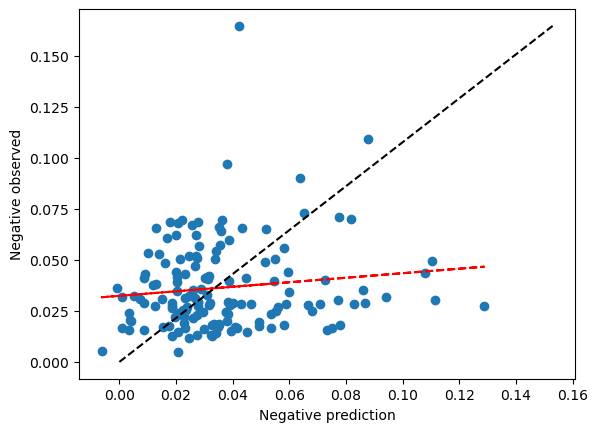

-1.535077391974513
0.03892117313913255
-0.5595443659355783
0.030527355062564505


In [19]:
# calculate r2 of un-bias corrected
from sklearn.metrics import r2_score
# calculate rmse of un-bias corrected
from sklearn.metrics import mean_squared_error

gdf_filtered["abs_negative_trend_mean"] = gdf_filtered["negative_trend_mean"].abs()
gdf_filtered["abs_negative_change_mean"] = gdf_filtered["negative_change_mean"].abs()

plt.scatter(gdf_filtered["abs_negative_trend_mean"], gdf_filtered["abs_negative_change_mean"])

# add trendline
z = np.polyfit(gdf_filtered["abs_negative_trend_mean"], gdf_filtered["abs_negative_change_mean"], 1)
p = np.poly1d(z)
plt.plot(gdf_filtered["abs_negative_trend_mean"],p(gdf_filtered["abs_negative_trend_mean"]),"r--")
#add 1 to 1 line
plt.plot([0,np.max(gdf_filtered["abs_negative_trend_mean"])],[0,np.max(gdf_filtered["abs_negative_change_mean"])], "k--")

plt.xlabel("Negative prediction")
plt.ylabel("Negative observed")
plt.show()

# calculate bias between positive prediction and positive observed
bias = gdf_filtered["abs_negative_change_mean"] - gdf_filtered["abs_negative_trend_mean"]
bias.mean()

#use bias to correct positive prediction
gdf_filtered["abs_negative_trend_corrected"] = gdf_filtered["abs_negative_trend_mean"] + bias.mean()

# recalculate r2
r2_score(gdf_filtered["abs_negative_trend_corrected"], gdf_filtered["abs_negative_change_mean"])

# replot

plt.scatter(gdf_filtered["abs_negative_trend_corrected"], gdf_filtered["abs_negative_change_mean"])

# add trendline
z = np.polyfit(gdf_filtered["abs_negative_trend_corrected"], gdf_filtered["abs_negative_change_mean"], 1)
p = np.poly1d(z)
plt.plot(gdf_filtered["abs_negative_trend_corrected"],p(gdf_filtered["abs_negative_trend_corrected"]),"r--")
#add 1 to 1 line
plt.plot([0,np.max(gdf_filtered["abs_negative_trend_mean"])],[0,np.max(gdf_filtered["abs_negative_change_mean"])], "k--")


plt.xlabel("Negative prediction")
plt.ylabel("Negative observed")
plt.show()


print(r2_score(gdf_filtered["abs_negative_trend_mean"], gdf_filtered["abs_negative_change_mean"]))

print(mean_squared_error(gdf_filtered["abs_negative_trend_mean"], gdf_filtered["abs_negative_change_mean"], squared=False))

print(r2_score(gdf_filtered["abs_negative_trend_corrected"], gdf_filtered["abs_negative_change_mean"]))

print(mean_squared_error(gdf_filtered["abs_negative_trend_corrected"], gdf_filtered["abs_negative_change_mean"], squared=False))




In [112]:
import random 
import matplotlib.pyplot as plt
import numpy as np

results_filtered = [r for r in results if r["trend"].max() != 0]
sumpool = nn.AvgPool2d(10, stride = 2)

results_pooled = []

pos_trend = []
neg_trend = []
pos_change = []
neg_change = []
plot=False

for result in results_filtered:
    try:
        early = result["early"]
        late = result["late"]
        trend = result["trend"]
        change = result["change"]
        early_pooled = sumpool(torch.tensor(early).unsqueeze(0).unsqueeze(0).float()).squeeze(0).squeeze(0).numpy()
        late_pooled = sumpool(torch.tensor(late).unsqueeze(0).unsqueeze(0).float()).squeeze(0).squeeze(0).numpy()
        trend_pooled = sumpool(torch.tensor(trend).unsqueeze(0).unsqueeze(0).float()).squeeze(0).squeeze(0).numpy()
        
        change_pooled = late_pooled - early_pooled
        
        #print(early.shape, late.shape, trend.shape)
        #print(early_pooled.shape, late_pooled.shape, trend_pooled.shape)
        
        results_dict = {"trend": trend_pooled, "early": early_pooled, "late": late_pooled, "change": change_pooled}
        results_pooled.append(results_dict)
        
        if plot:
            if np.sum(change_pooled) < -20000 or np.sum(trend_pooled) > 10000:
                
                print(np.mean(change_pooled), np.mean(trend_pooled))
                fig, ax = plt.subplots(2, 2, figsize=(10, 10))
                ax[0,0].imshow(change_pooled)
                ax[0,1].imshow(change)
                ax[1,0].imshow(trend_pooled)
                ax[1,1].imshow(trend)
                plt.show()
            
        pos_trend.append(np.sum(trend_pooled[trend_pooled > 0]))
        neg_trend.append(np.sum(trend_pooled[trend_pooled < 0]))
        pos_change.append(np.sum(change_pooled[change_pooled > 0]))
        neg_change.append(np.sum(change_pooled[change_pooled < 0]))
    except Exception as e:
        #print(e)
        continue
    
    
    

In [14]:
print(len(results_pooled))

plt.scatter(pos_trend, pos_change)
#line 
plt.plot(np.unique(pos_trend), np.poly1d(np.polyfit(pos_trend, pos_change, 1))(np.unique(pos_trend)), color="red")
plt.xlabel("predicted change")
plt.ylabel("actual change")

# calculate r2
from sklearn.metrics import r2_score
r2_score(pos_trend, pos_change)



NameError: name 'results_pooled' is not defined

-1.7843431287753542

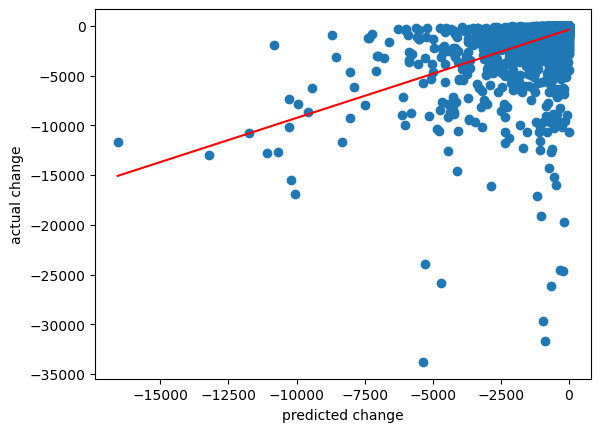

In [115]:
plt.scatter(neg_trend, neg_change)
#line 
plt.plot(np.unique(neg_trend), np.poly1d(np.polyfit(neg_trend, neg_change, 1))(np.unique(neg_trend)), color="red")
plt.xlabel("predicted change")
plt.ylabel("actual change")

# calculate r2
from sklearn.metrics import r2_score
r2_score(neg_trend, neg_change)

In [ ]:

# random sample 10 from results and plot trend vs change
sample = random.sample(results_filtered, 10)
for r in results_filtered[:100]:
    
    print(r["trend"].min(), r["trend"].max())
    
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(r["trend"])
    ax[0].set_title("Trend")
    ax[1].imshow(r["change"])
    ax[1].set_title("Change")
    plt.show()

In [13]:
print(len(results_filtered))
trend_sums = [r["trend"].sum() for r in results_filtered]
change_sums = [r["change"].sum() for r in results_filtered]

plt.scatter(trend_sums, change_sums)
#line 
plt.plot(np.unique(trend_sums), np.poly1d(np.polyfit(trend_sums, change_sums, 1))(np.unique(trend_sums)), color="red")
plt.xlabel("predicted change")
plt.ylabel("actual change")


NameError: name 'results_filtered' is not defined

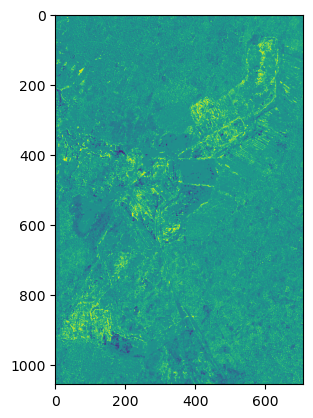

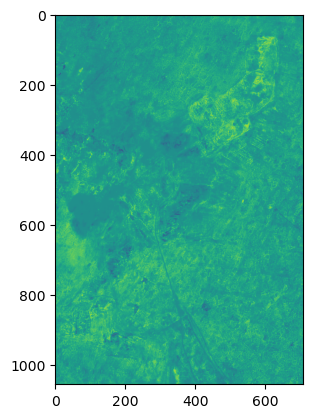

-1.0 1.0 -0.5643935 0.84001434
60265.203 0.080416545 107610.67 0.14359328


In [59]:
plt.imshow(change)
plt.show()
plt.imshow(trend_data, vmin=change.min(), vmax=change.max())
plt.show()
print(change.min(), change.max(), trend_data.min(), trend_data.max())
print(np.sum(change), np.mean(change), np.sum(trend_data), np.mean(trend_data))